In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import scipy.io
from collections import Counter
from sklearn.metrics import r2_score
from tqdm import tqdm

from GroupMultiNeSS.utils import fill_diagonals, estimate_sigma_mad, fisher_transform, \
    MultipleNetworkTrainTestSplitter, avg_lp_error, pairwise_metric_matrix, cos_sim
from GroupMultiNeSS.group_multiness import GroupMultiNeSSCV, GroupMultiNeSS
from GroupMultiNeSS.multiness import MultiNeSS, MultiNeSSCV
from GroupMultiNeSS.data_generation import GroupLatentPositionGenerator
from GroupMultiNeSS.MASE import ASE


sys.path.append(os.path.abspath(".."))
from utils.utils import cluster_distance_matrix, align_latent_spaces, upper_tri_list_to_matrix
from utils.real_data_utils import construct_cell_matrix, cell_matrix_permutation_test, \
    make_layers_and_group_indices_from_attributes, regress_out_covariate_effects
from utils.plot_utils import plot_eigvals_elbow_plot, plot_pvals_heatmap, plot_multiplex_edge_predictions, \
    compare_pairwise_matrix_metric, plot_latent_positions, plot_sim_metric_heatmap, significance_heatmap

## Load atlas & data



In [2]:
# SHOULD BE IN THE SAME FOLDER AS THE NOTEBOOK!!!
atlas = pd.read_csv("aal116_labels.csv")
regions = atlas["lobe"].values
hemispheres = atlas["hemi"].values
Counter(regions), Counter(hemispheres)

(Counter({'Frontal': 28,
          'Cerebellum': 26,
          'Occipital': 14,
          'Parietal': 14,
          'Limbic': 12,
          'Temporal': 12,
          'SCGM': 8,
          'Insula': 2}),
 Counter({'L': 58, 'R': 58}))

In [3]:
# SHOULD BE IN THE SAME FOLDER AS THE NOTEBOOK!!!
metadata = pd.read_csv("Metadata_v5/TaoWu_metadata.csv")

In [4]:
# SHOULD BE IN THE SAME FOLDER AS THE NOTEBOOK!!!

data_path =  "taowu/"
patient_folders = [folder for folder in os.listdir(data_path) if folder.startswith("sub-")]
len(patient_folders)

subject_2_matrix = {}

for patient_folder in patient_folders:
    subject =  patient_folder[4:] # delete sub- at the beginning
    file_name = patient_folder + '_AAL116_correlation_matrix.mat'
    file_path = os.path.join(data_path, patient_folder, file_name)
    cor_mat = scipy.io.loadmat(file_path)["data"]
#     np.fill_diagonal(cor_mat, 0.)
    subject_2_matrix[subject] = cor_mat
    

patients = [key for key in subject_2_matrix if key.startswith("patient")]
controls = [key for key in subject_2_matrix if key.startswith("control")]

# Preliminary analysis 1: Some statistics

In [5]:
print("Number of patients:", len(metadata))
metadata.head(5)

Number of patients: 40


,Subject,Group,Sex,Age
0,control032057,Control,F,64
1,control032058,Control,M,73
2,control032059,Control,M,67
3,control032060,Control,M,70
4,control032061,Control,F,75


In [6]:
print("Sex distribution:", dict(Counter(metadata["Sex"])))
print("Control/Parkinson distribution:", dict(Counter(metadata["Group"])))

Sex distribution: {'F': 17, 'M': 23}
Control/Parkinson distribution: {'Control': 20, 'PD': 20}


Median age: 64.0 Mean age: 64.975


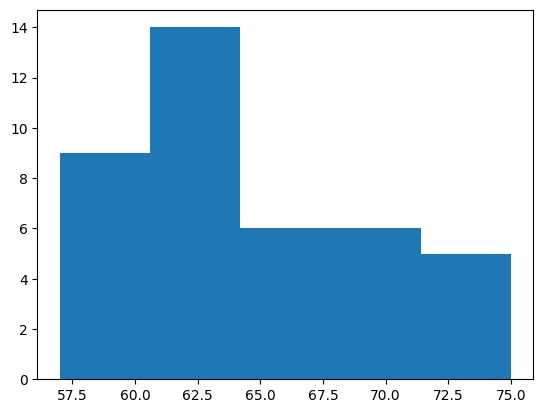

In [7]:
print("Median age:", np.median(metadata["Age"]), "Mean age:", np.mean(metadata["Age"]))
# sorted(Counter(metadata["Age"]).items(), key=lambda x: x[0])
plt.hist(metadata["Age"], bins=5)
plt.show()

In [8]:
def plot_sample(subject_2_matrix, subject_sample):
    fig, axs = plt.subplots(ncols=len(subject_sample), figsize=(20, 5))
    for ax, subject in zip(axs, subject_sample):
        matrix = subject_2_matrix[subject]
        tri_mask = np.triu(np.ones_like(matrix, dtype=bool))
        sns.heatmap(matrix, ax=ax, mask=tri_mask)
        ax.set_title(subject)
    plt.show()
    
def plot_eigvals_elbow_plots_across_subjects(subject_2_matrix, subject_sample, 
                                             normalize=True, marker=None):
    fig, axs = plt.subplots(ncols=len(subject_sample), figsize=(20, 5))
    for ax, subject in zip(axs, subject_sample):
        matrix = subject_2_matrix[subject]
        plot_eigvals_elbow_plot(matrix, ax=ax, normalize=normalize, title=subject, marker=None)  
    plt.show()    

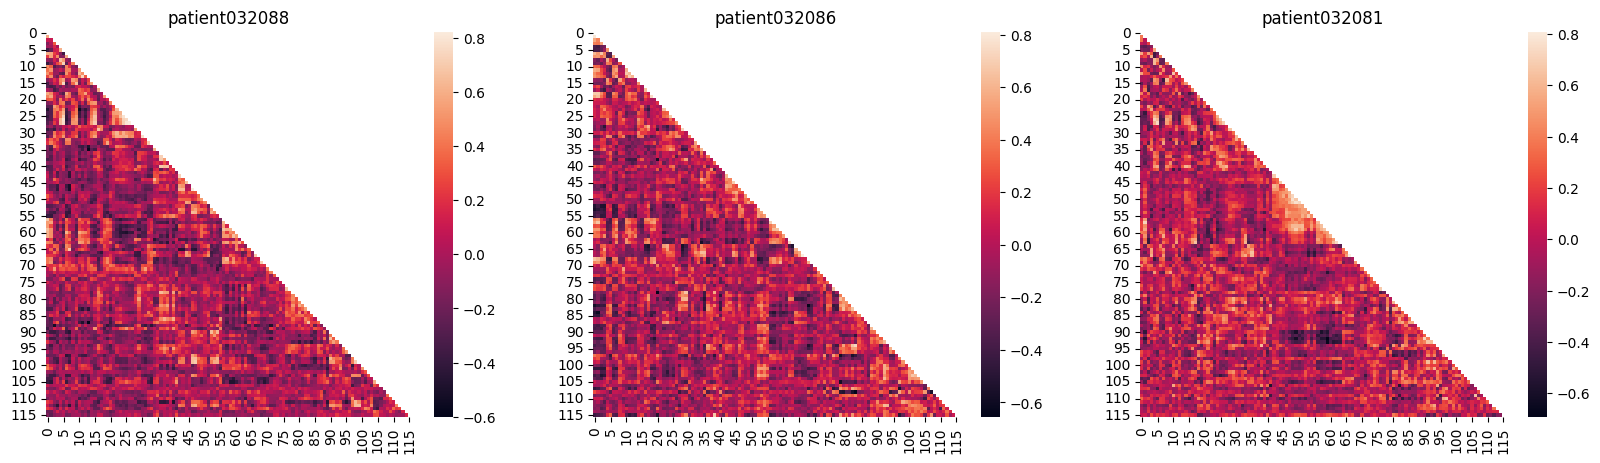

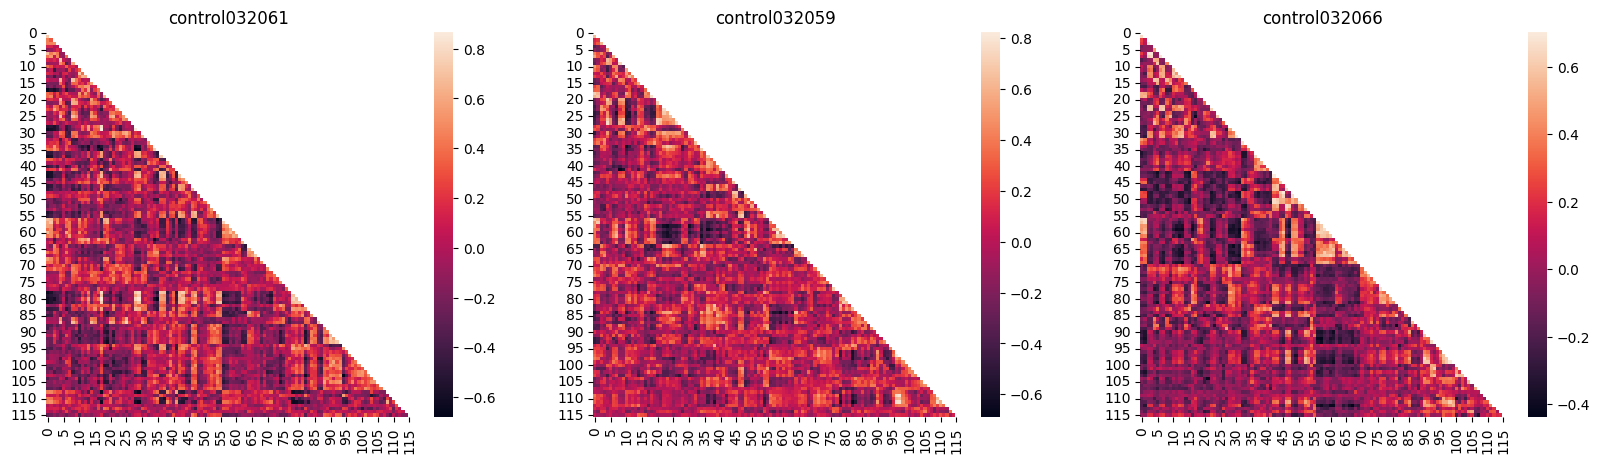

In [9]:
plot_sample(subject_2_matrix, patients[:3])
plot_sample(subject_2_matrix, controls[:3])

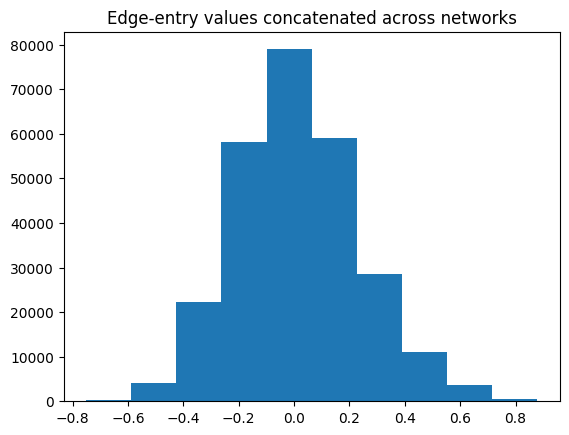

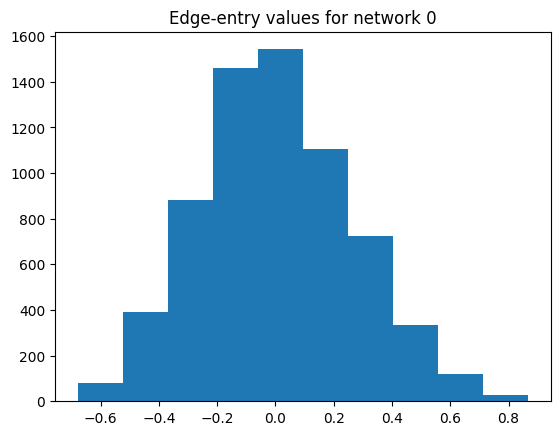

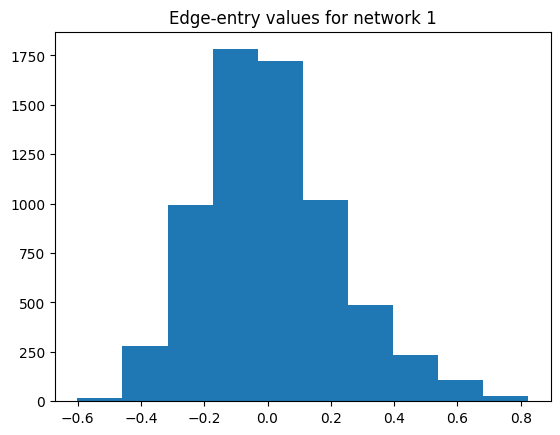

In [10]:
triu_indices = np.triu_indices(n=116, k=1)
cor_values = [mat[triu_indices] for mat in subject_2_matrix.values()]
plt.hist(np.concatenate(cor_values))
plt.title("Edge-entry values concatenated across networks")
plt.show()
         
for i in range(2):
    plt.hist(cor_values[i])
    plt.title(f"Edge-entry values for network {i}")
    plt.show()

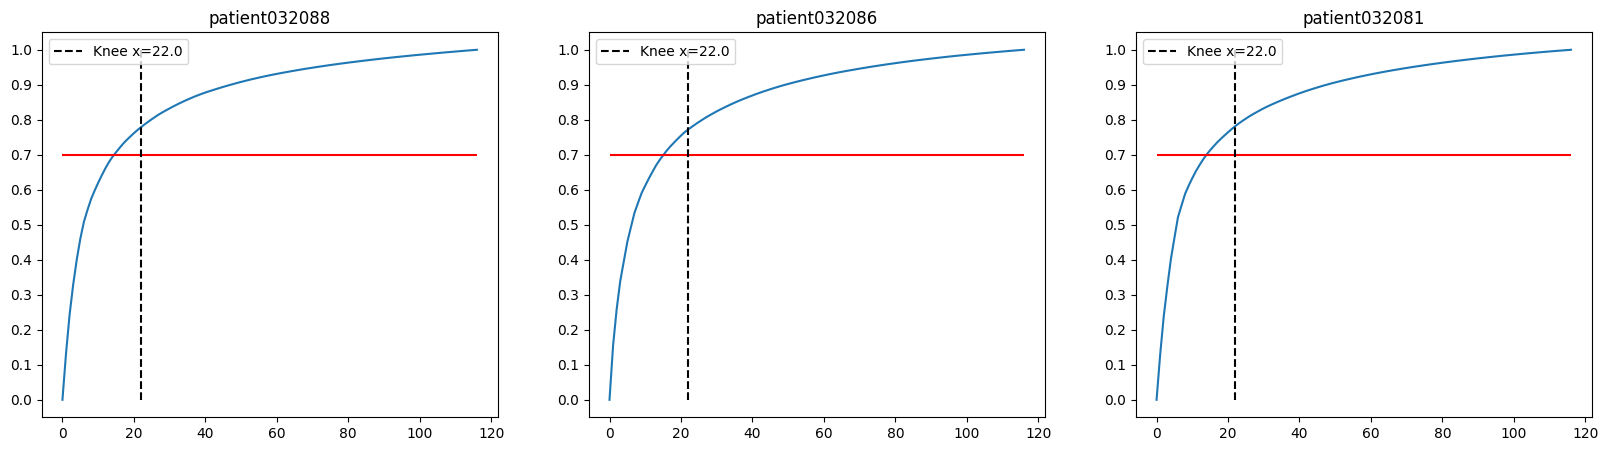

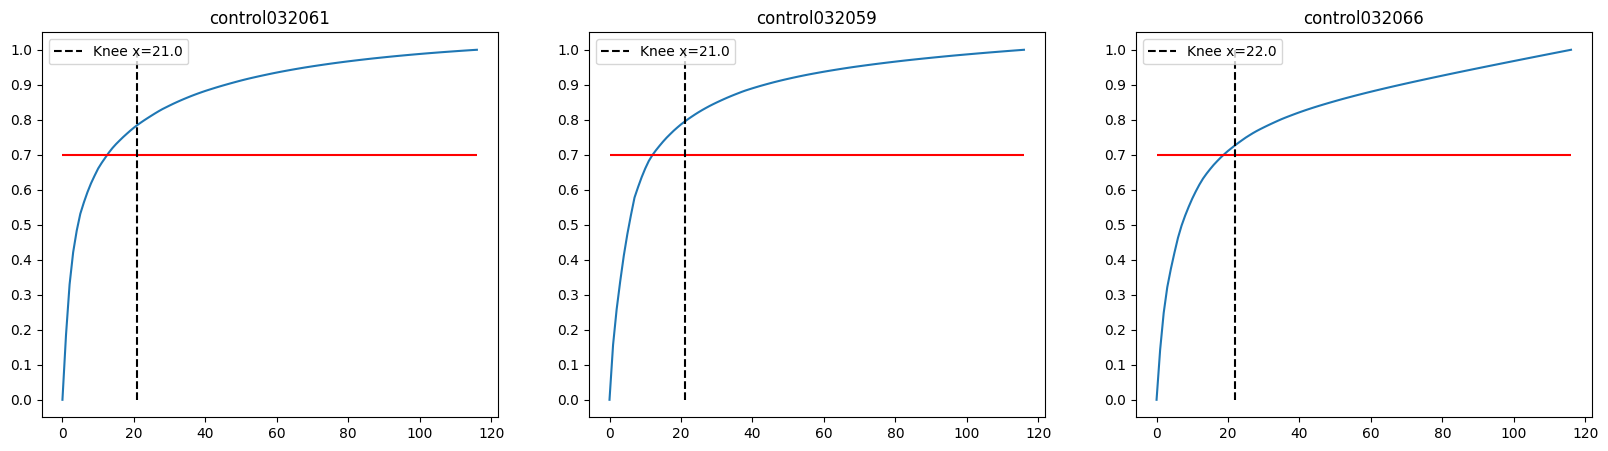

In [12]:
plot_eigvals_elbow_plots_across_subjects(subject_2_matrix, patients[:3])
plot_eigvals_elbow_plots_across_subjects(subject_2_matrix, controls[:3])

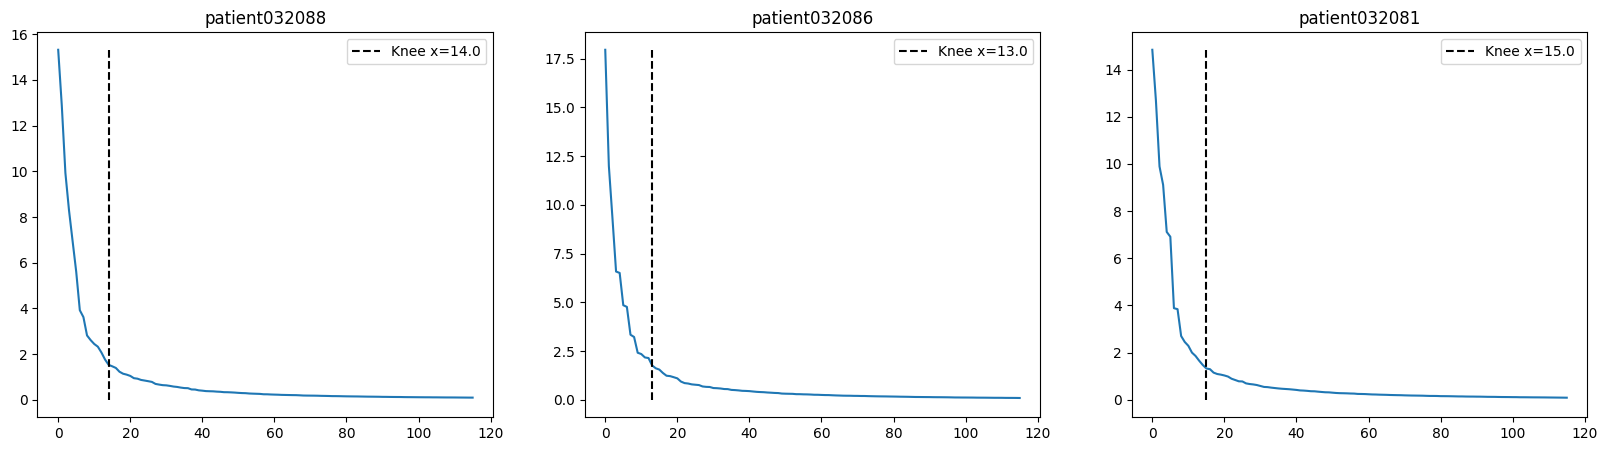

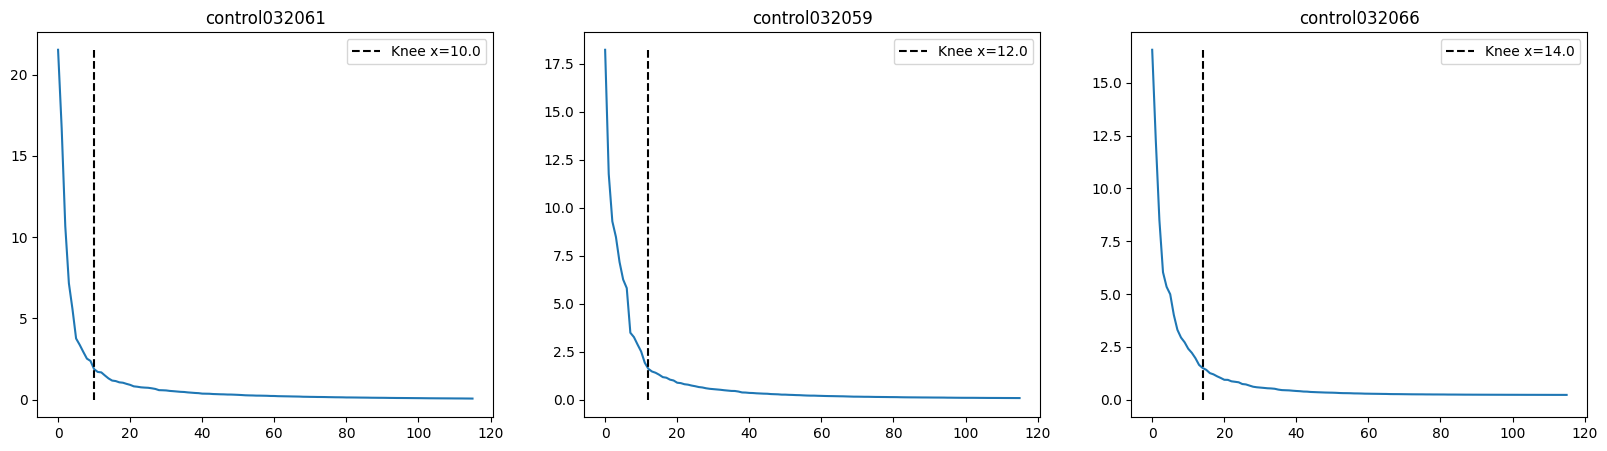

In [13]:
plot_eigvals_elbow_plots_across_subjects(subject_2_matrix, patients[:3], normalize=False)
plot_eigvals_elbow_plots_across_subjects(subject_2_matrix, controls[:3], normalize=False)

# Preliminary analysis 2: Naive premutation test  on cell-cell inetractions

## Construct the groups

In [14]:
# Apply Fisher transform 
subject_2_ft_matrix = {subject: fisher_transform(cor_mat) for subject, cor_mat in subject_2_matrix.items()}

In [15]:
attrs_to_form_groups = ["Group"]
# attrs_to_form_groups = ["Group"]
As, subjects, group_indices, group_2_index = make_layers_and_group_indices_from_attributes(
    subject_2_ft_matrix, metadata, attrs_to_form_groups=attrs_to_form_groups)

print(As.shape, group_indices.shape)

M, n, _ = As.shape
K = len(np.unique(group_indices))
print(f"Number of nodes: {n}, number of layers: {M}, number of groups: {K}")

Counter({('Control',): 20, ('PD',): 20})
(40, 116, 116) (40,)
Number of nodes: 116, number of layers: 40, number of groups: 2


In [21]:
def mean_abs_transform(x):
    return np.mean(np.abs(x))

def median_abs_transform(x):
    return np.median(np.abs(x))

def rms_transform(x):
    return np.sqrt(np.mean(x ** 2))

1) Visual Dysfunction in Parkinson’s Disease (https://pmc.ncbi.nlm.nih.gov/articles/PMC10452537/)
"These structural and functional changes in the occipital lobe can contribute to various visual dysfunctions, such as impaired visual processing, difficulty with spatial orientation, and visual hallucinations" 
2) "Abnormal connectivity in the visual network may be related to adaptation and compensation processes as a consequence of altered motor function." (https://pubmed.ncbi.nlm.nih.gov/24204812/)

## Permutation tests with different aggregations of region-region interactions into cell-cell interactions

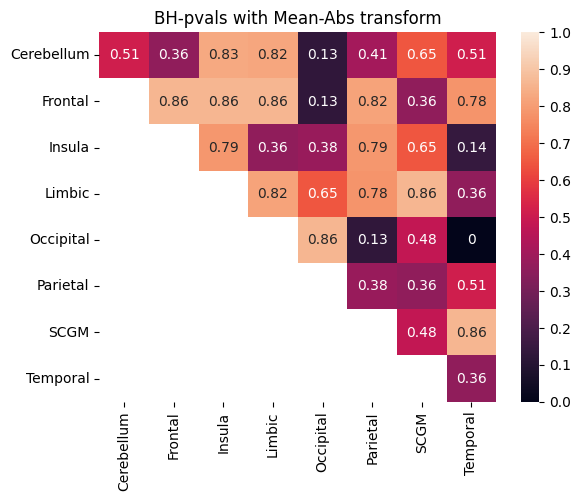

In [17]:
cell_matrices = [construct_cell_matrix(cor_matrix=A, regions=regions, transform=mean_abs_transform) 
                 for A in As]
pval_df, adj_pval_df = cell_matrix_permutation_test(cell_matrices, group_indices, n_permutations=10000)
plot_pvals_heatmap(adj_pval_df, "BH-pvals with Mean-Abs transform")

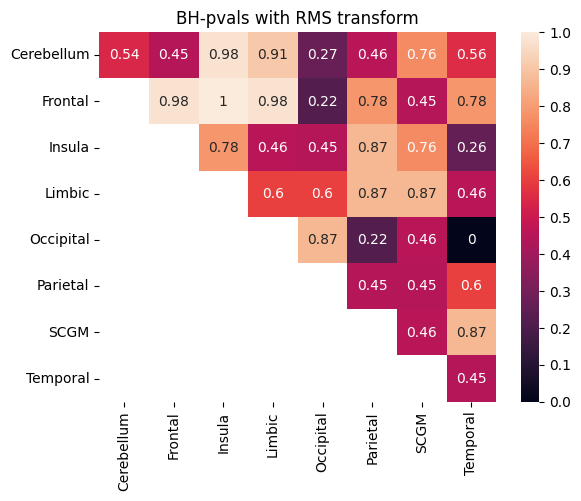

In [18]:
# RMS transform
cell_matrices = [construct_cell_matrix(cor_matrix=A, regions=regions, transform=rms_transform) for A in As]
pval_df, adj_pval_df = cell_matrix_permutation_test(cell_matrices, group_indices, n_permutations=10000)

plot_pvals_heatmap(adj_pval_df, "BH-pvals with RMS transform")

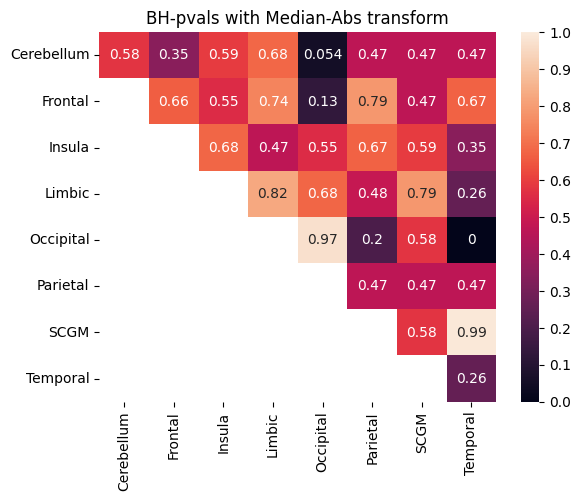

In [19]:
# Median-abs transform
cell_matrices = [construct_cell_matrix(cor_matrix=A, regions=regions, transform=median_abs_transform) 
                 for A in As]
pval_df, adj_pval_df = cell_matrix_permutation_test(cell_matrices, group_indices, n_permutations=10000)

plot_pvals_heatmap(adj_pval_df, "BH-pvals with Median-Abs transform")

# Main Analysis: Fitting MultiNeSS & GroupMultiNeSS

In [22]:
# Regress out the differences in other attributes
covariates = list(set(["Group", "Sex", "Age"]) - set(attrs_to_form_groups))
As_resids, coefs_table, cell_2_ys = regress_out_covariate_effects(As, subjects=subjects, metadata=metadata, 
                                                                  covariates=covariates, include_intercept=True)

In [28]:
attrs_to_form_groups = ["Group"]
# attrs_to_form_groups = ["Group"]
As, subjects, group_indices, group_2_index = make_layers_and_group_indices_from_attributes(
    subject_2_ft_matrix, metadata, attrs_to_form_groups=attrs_to_form_groups)

print(As.shape, group_indices.shape)

M, n, _ = As.shape
K = len(np.unique(group_indices))
print(f"Number of nodes: {n}, number of layers: {M}, number of groups: {K}")


# Regress out the differences in other attributes
covariates = list(set(["Group", "Sex", "Age"]) - set(attrs_to_form_groups))
As_resids, coefs_table, cell_2_ys = regress_out_covariate_effects(As, subjects=subjects, metadata=metadata, 
                                                                  covariates=covariates, include_intercept=True)

Counter({('Control',): 20, ('PD',): 20})
(40, 116, 116) (40,)
Number of nodes: 116, number of layers: 40, number of groups: 2


In [29]:
coefs_table

,Intercept,Age,Sex_M
"(0, 1)",0.682339,0.026265,-0.091272
"(0, 2)",0.260289,0.059416,-0.022698
"(0, 3)",0.128734,0.063922,-0.05292
"(0, 4)",-0.119991,-0.023474,-0.00644
"(0, 5)",-0.167661,-0.082693,0.01367
...,...,...,...
"(112, 114)",0.136004,0.008883,-0.027103
"(112, 115)",-0.013531,0.000503,-0.079845
"(113, 114)",0.266315,0.038981,-0.031259
"(113, 115)",0.054801,-0.05096,-0.041812


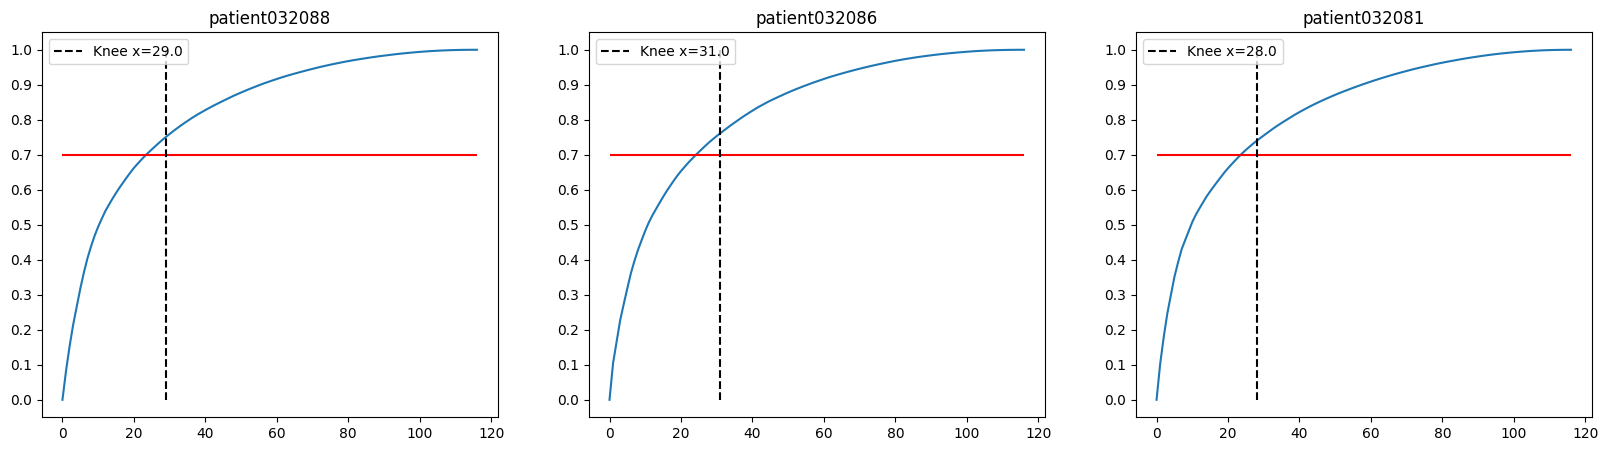

In [30]:
plot_eigvals_elbow_plots_across_subjects({subj: mat for subj, mat in zip(subjects, As_resids)},
                                         subject_sample=patients[:3], normalize=True)

In [31]:
# for cell, y_dict in list(cell_2_ys.items())[:10]:
#     plt.plot
#     plt.scatter(y_dict["y_true"], y_dict["y_pred"])
#     plt.title(cell)
#     plt.show()

In [32]:
# plt.hist(coefs_table["Sex_M"])

In [33]:
cell_2_r2_score = {cell: r2_score(y_dic["y_true"], y_dic["y_pred"]) for cell, y_dic in cell_2_ys.items()}

0.03103448275862069


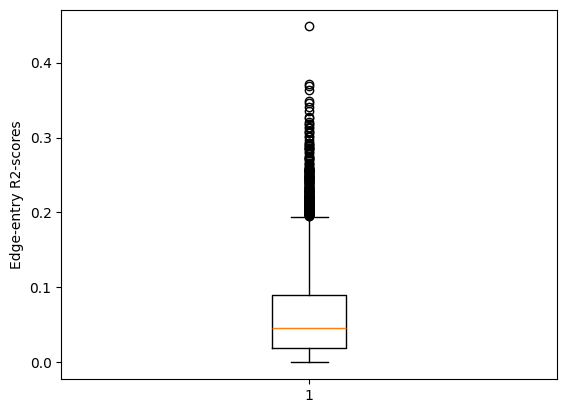

In [34]:
print((np.array(list(cell_2_r2_score.values())) > 0.2).mean())
plt.boxplot(cell_2_r2_score.values())
plt.ylabel("Edge-entry R2-scores")
plt.show()

## Comparing MN & GMN in terms of the error on test edge-entris

In [36]:
def avg_relative_lp_error(y_true: np.ndarray, y_pred: np.ndarray, p=2):
    assert y_true.shape == y_pred.shape
    abs_diff_norm = np.nansum(np.abs(y_true - y_pred) ** p) ** (1. / p)
    true_norm = np.nansum(np.abs(y_true) ** p) ** (1. / p)
    return abs_diff_norm / true_norm

In [37]:
lmbda1_range = np.sqrt(n * M / K) * np.array([0.003, 0.01, 0.03, 0.1, 0.3])
lmbda2_range = M * np.sqrt(n / K) * np.array([0.001, 0.003, 0.01, 0.03, 0.1])

In [38]:
init_kwargs = {"edge_distrib": "normal", "loops_allowed": False, "sigmas": None}
fit_kwargs = {"lr": 1., "tol": 1e-5, "verbose": False, "verbose_interval": 10, "max_iter": 200}
param_grid_gmn = {'lmbda1': lmbda1_range, 'lmbda2': lmbda2_range}
param_grid_mn = {'lmbda': np.sqrt(n * M) * np.array([0.003, 0.01, 0.03, 0.1, 0.3])}

In [19]:
test_props = [0.1, 0.3, 0.5, 0.7, 0.9]

gmn_errors = []
mn_errors = []

for test_prop in tqdm(test_props):
    tts = MultipleNetworkTrainTestSplitter(loops_allowed=False, fix_layer_split=True, random_seed=1)
    As_train, As_test = tts.train_test_split(As)
    
    group_multiness = GroupMultiNeSSCV(param_grid=param_grid_gmn, group_indices=group_indices,  max_rank=7,
                                       **init_kwargs)
    group_multiness.fit(As_train, **fit_kwargs)
    As_pred_gmn = group_multiness.compute_expected_adjacency()
    gmn_errors.append(avg_relative_lp_error(As_test, As_pred_gmn))
    
    multiness = MultiNeSSCV(param_grid=param_grid_mn, max_rank=14, **init_kwargs)
    multiness.fit(As_train, **fit_kwargs)
    As_pred_mn = multiness.compute_expected_adjacency()
    mn_errors.append(avg_relative_lp_error(As_test, As_pred_mn))


Text(0, 0.5, 'Mean Squared Error')

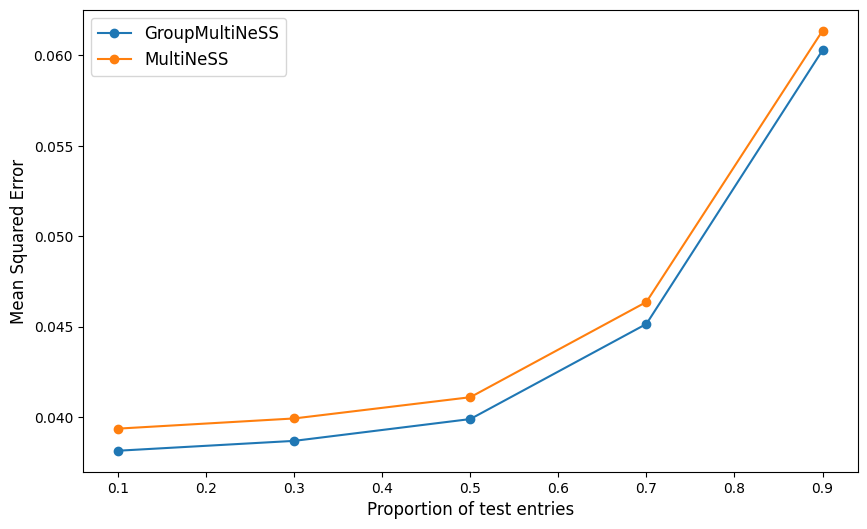

In [77]:
fontsize=12
plt.figure(figsize=(10, 6))
plt.plot(test_props, gmn_errors, marker='o', label="GroupMultiNeSS")
plt.plot(test_props, mn_errors, marker='o', label="MultiNeSS")
plt.legend(fontsize=fontsize)
plt.xlabel("Proportion of test entries", fontsize=fontsize)
plt.ylabel("Mean Squared Error", fontsize=fontsize)

In [41]:
As_train, As_test = multiplex_networks_train_test_split(As, random_seed=1, fix_layer_split=False)

In [27]:
group_multiness = GroupMultiNeSSCV(group_indices, param_grid=param_grid, max_rank=10, 
                                   method="stepwise", **init_kwargs)

group_multiness.fit(As_train, **fit_kwargs)

In [856]:
# group_multiness.plot_nll_history(figsize=(10, 3), fontsize=10)

In [857]:
multiness = MultiNeSS(lmbda=0.1 * np.sqrt(n * M), max_rank=15, **init_kwargs)
multiness.fit(As_train, **fit_kwargs)

Python(61631) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [858]:
As_pred_gmn = group_multiness.compute_expected_adjacency()
avg_lp_error(As_test, As_pred_gmn)

0.04612735844390484

In [859]:
As_pred_mn = multiness.compute_expected_adjacency()
avg_lp_error(As_test, As_pred_mn)

0.047529849885734846

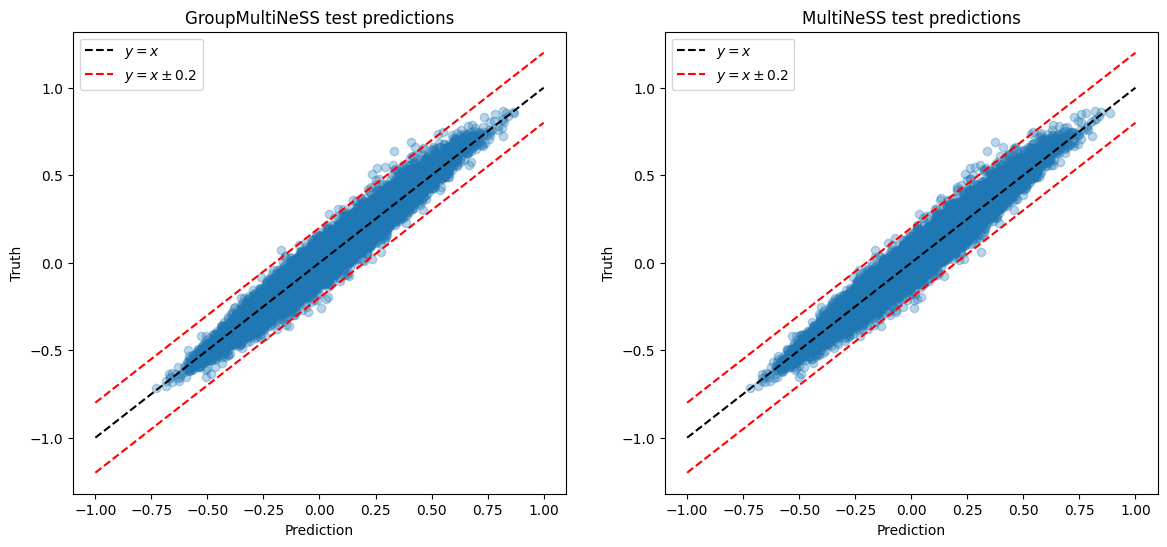

In [860]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))
plot_multiplex_edge_predctions(As_test, As_pred_gmn, title="GroupMultiNeSS test predictions", ax=axs[0])
plot_multiplex_edge_predctions(As_test, As_pred_mn, title="MultiNeSS test predictions", ax=axs[1])

## Fitting GroupMultiNeSS to Treatment/Control groups

In [39]:
init_kwargs = {"edge_distrib": "normal", "loops_allowed": False, "sigmas": None, "max_rank": 20}
fit_kwargs = {"lr": 0.8, "tol": 1e-5, "verbose": False, "verbose_interval": 10, 
              "max_iter": 200, "refit": True}

In [34]:
lmbda1_range = np.sqrt(n * M / K) * np.array([0.003, 0.01, 0.03, 0.1, 0.3])
lmbda2_range = M * np.sqrt(n / K) * np.array([0.001, 0.003, 0.01, 0.03, 0.1])

# Eventually did not do CV for alpha
# alpha1_range = 1 / np.sqrt(M / K) * np.array([1, 3, 5])
# alpha2_range = 1 / np.sqrt(K) * np.array([1, 3, 5,])
 
param_grid = {"lmbda1": lmbda1_range,  "lmbda2": lmbda2_range}

group_multiness = GroupMultiNeSSCV(group_indices,
                                   param_grid=param_grid, 
                                   n_jobs=K,
                                   cv_folds=5, 
                                   use_1se_rule=True,
                                   fix_layer_split=True, 
                                   random_seed=1,
                                   refit_threshold=1e-5,
                                   **init_kwargs)

%time group_multiness.fit(As_resids, **fit_kwargs)

CPU times: user 15min 25s, sys: 10min 52s, total: 26min 18s
Wall time: 23min 31s


In [21]:
best_gmn_cv_dict = group_multiness.get_best_params_dict()
best_gmn_cv_dict

{(0, 0): {'lmbda1': 1.4449913494550755},
 (0, 1): {'lmbda1': 1.4449913494550755},
 (1, 0): {'lmbda2': 3.0463092423455636}}

In [18]:

lmbda1s_cv = [best_gmn_cv_dict[(0, k)]["lmbda1"] for k in range(K)]
lmbda2_cv = best_gmn_cv_dict[(1, 0)]["lmbda2"]
lmbda1s_cv, lmbda2_cv

([1.4449913494550755, 1.4449913494550755], 3.0463092423455636)

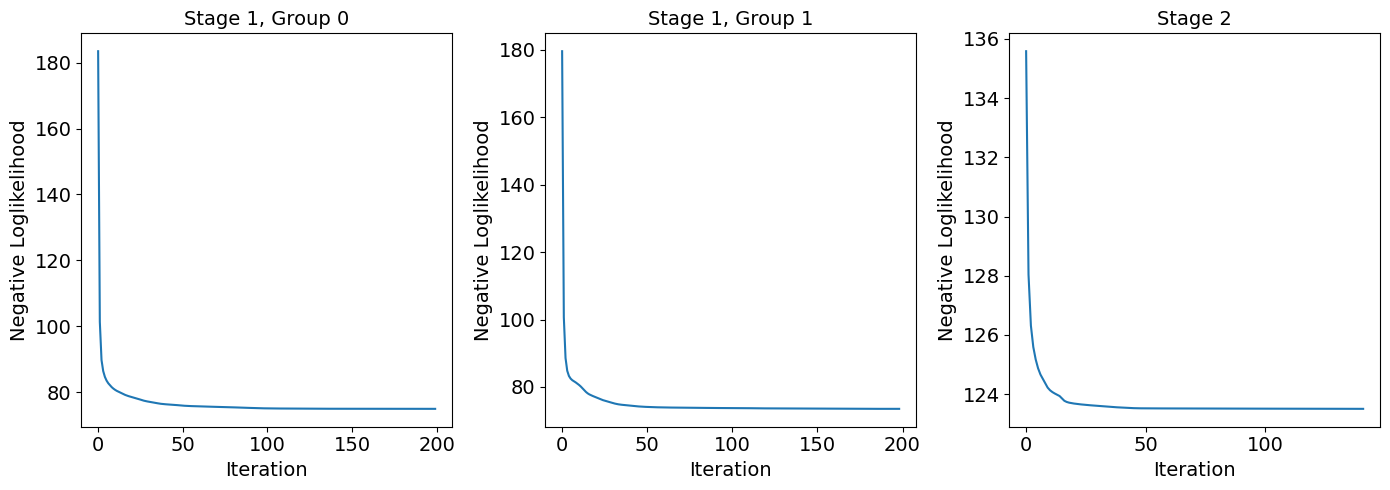

{(0, 0): {'lmbda1': 1.4449913494550755}, (0, 1): {'lmbda1': 1.4449913494550755}, (1, 0): {'lmbda2': 3.0463092423455636}}


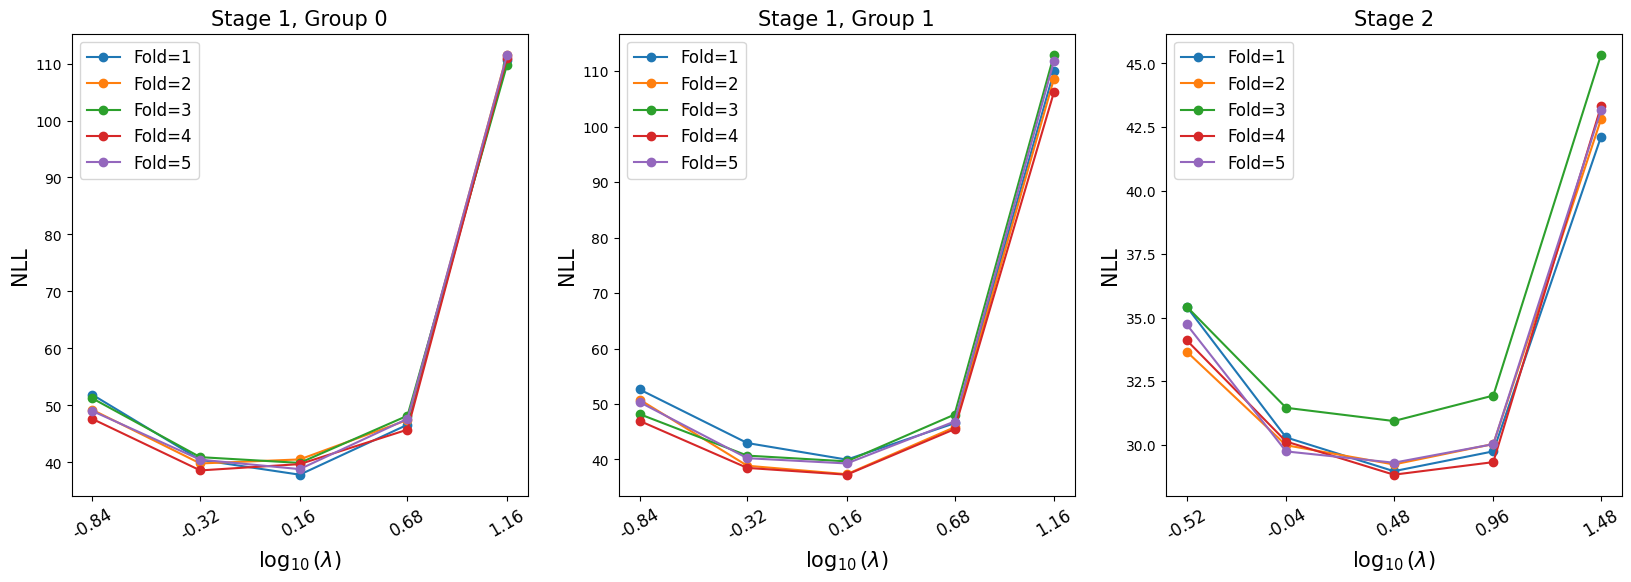

In [35]:
# Check Convergence 

group_multiness.plot_nll_history(figsize=(14, 5))
print(group_multiness.get_best_params_dict())
group_multiness.plot_cv_results()

In [ ]:
S, Qs, Rs = group_multiness.get_all_fitted_matrices_by_type()

In [36]:
# SAVE

with open(f"saved_results/taowu_gmn_final_latent_components_with_fisher_transform.npy", "wb") as f:
    np.save(f, group_multiness.get_all_fitted_matrices())

In [54]:
# OPEN

with open(f"saved_results/taowu_gmn_final_latent_components_with_fisher_transform.npy", "rb") as f:
    all_mats = np.load(f)
    all_ases = [ASE(matrix, d=3, check_if_symmetric=True) for matrix in all_mats]
    assert len(all_mats) == 1 + K + M 
    S, Qs, Rs = all_mats[0], all_mats[1: K + 1], all_mats[K + 1:]
    V_gmn, Ws_gmn, Us_gmn = all_ases[0], all_ases[1: K + 1], all_ases[K + 1:]
    Ws_gmn_aligned = align_latent_spaces(Ws_gmn)

In [56]:
# Equivalent to running two separate MultiNeSS models (see paper)
from GroupMultiNeSS.utils import make_group_averages

Qs_mn = make_group_averages(As_resids - Rs, group_indices=group_indices, groups=[0, 1])

Ws_mn = [ASE(Q, d=3, check_if_symmetric=False) for Q in Qs_mn]
Ws_mn_aligned = align_latent_spaces(Ws_gmn + Ws_mn)[-K:]


In [57]:
tol = 1e-5

print('Ranks:', np.linalg.matrix_rank(S, tol=tol), [np.linalg.matrix_rank(Q, tol=tol) for Q in Qs], 
      np.mean([np.linalg.matrix_rank(R, tol=tol) for R in Rs]))

print("Frobenius norms:", np.linalg.norm(S, ord="f"), np.linalg.norm(Qs, ord="f", axis=(1, 2)), 
      np.mean(np.linalg.norm(Rs, ord="f", axis=(1, 2))))

Ranks: 20 [20, 20] 20.0
Frobenius norms: 2.310717349135143 [2.7536634  3.55310837] 21.43447330799982


In [58]:
# compare_pairwise_matrix_metric([Rs], ["GroupMultiNeSS Individ comps"], max_rank=3)
# compare_pairwise_matrix_metric([Qs], ["GroupMultiNeSS Group comps"], max_rank=10)

In [59]:
index_2_group = {index: group for group, index in group_2_index.items()}
group_labels = [index_2_group[idx] for idx in range(K)]

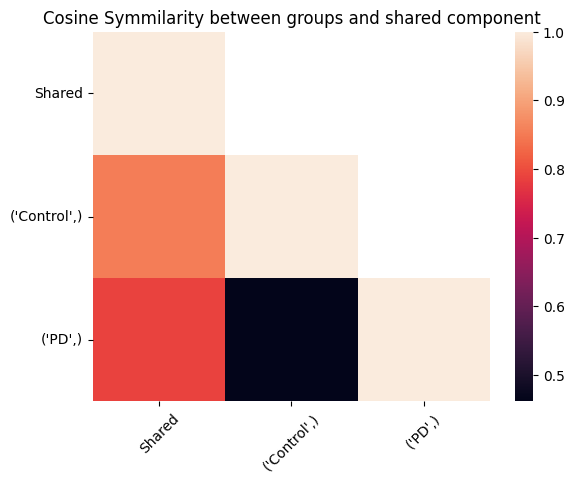

In [60]:
# plot_sim_metric_heatmap(Ws_gmn, procrustes_distance, labels=group_labels, 
#                         title="Procrustes distance between groups", relative=True)
plot_sim_metric_heatmap([S, *Qs], cos_sim, labels=["Shared"] + group_labels, 
                        title="Cosine Symmilarity between groups and shared component")
# plot_sim_metric_heatmap(Us_gmn, procrustes_distance, title="Procrustes distance between individ comps")

## Plot latent positions

In [61]:
Counter(regions)

Counter({'Frontal': 28,
         'Cerebellum': 26,
         'Occipital': 14,
         'Parietal': 14,
         'Limbic': 12,
         'Temporal': 12,
         'SCGM': 8,
         'Insula': 2})

In [62]:
regions_of_interest = ["Frontal", 'Cerebellum', 'Occipital', 'Temporal', "Parietal"]
# regions_of_interest = np.unique(regions)
regions_mask = np.isin(regions, regions_of_interest)
print(f"Overall {regions_mask.sum()} regions selected for analysis")

Overall 94 regions selected for analysis


In [63]:
svs_s = np.linalg.svd(S, compute_uv=False)
svs_q0 = np.linalg.svd(Qs[0], compute_uv=False)
svs_q1 = np.linalg.svd(Qs[1], compute_uv=False)

In [64]:
svs_q0[:3].sum() / svs_q0.sum(), svs_q1[:3].sum() / svs_q1.sum()

(0.43539225889074235, 0.4698818553785294)

In [65]:
def extract_leading_dims_signature(A, d):
    assert np.allclose(A, A.T)
    eigs = np.array(sorted(np.real(np.linalg.eig(A)[0]), 
                           key=abs, reverse=True))[:d]
    
    p, q = (eigs >= 0).sum(), (eigs < 0).sum(),
    return p, q

print("Signature of Q_0:", extract_leading_dims_signature(Qs[0], d=3))
print("Signature of Q_1:", extract_leading_dims_signature(Qs[1], d=3))
print("Signature of S:", extract_leading_dims_signature(S, d=4))

Signature of Q_0: (0, 3)
Signature of Q_1: (0, 3)
Signature of S: (0, 4)


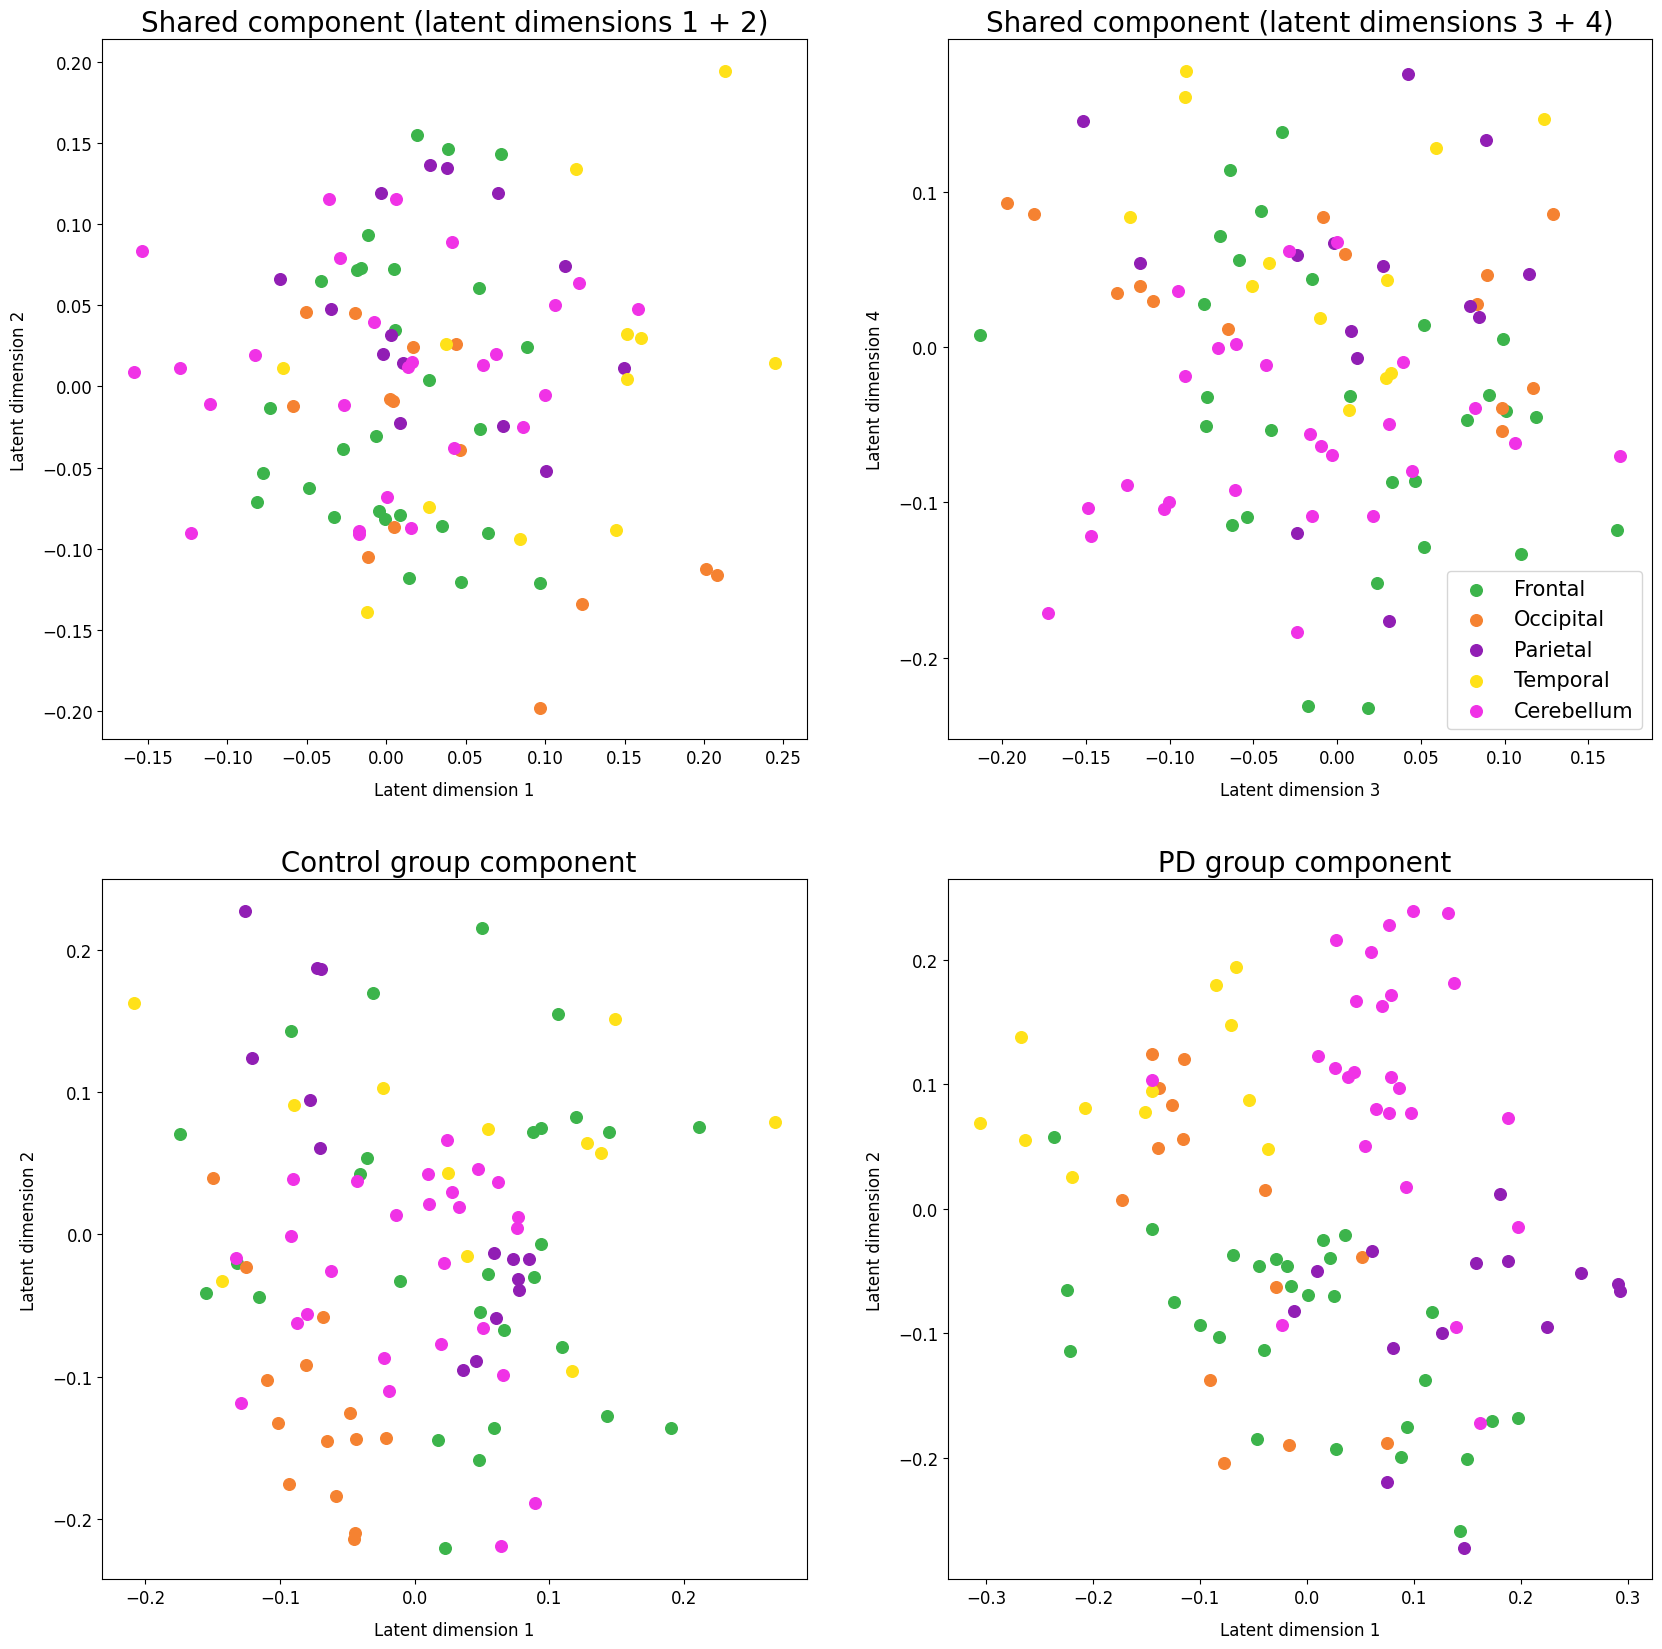

In [68]:
fontsize=12
markersize=70
colors = ["#f032e6", "#3cb44b", "#e6194b", "#0082c8", "#f58231", "#911eb4", "pink", "#ffe119"]
node_type_2_color = dict(zip(np.unique(regions), colors))
node_shapes = None
alpha = 1

fig, axs = plt.subplots(2, 2, figsize=(20, 20))

V_gmn = ASE(S, d=4)
for i, dims in enumerate([(0, 1), (2, 3)]):
    plot_latent_positions(V_gmn[regions_mask], 
                          node_types=regions[regions_mask], 
                          node_type_2_color=node_type_2_color,
                          title=f"Shared component (latent dimensions {dims[0] + 1} + {dims[1] + 1})",  
                          fontsize=fontsize, dims=dims,
                          plot_legend = i==1,
                          ax=axs[0, i],
                          markersize=markersize, alpha=alpha)

for i in range(2):
    plot_latent_positions(Ws_gmn_aligned[i][regions_mask], 
                          node_types=regions[regions_mask], 
                          node_type_2_color=node_type_2_color,
                          title=f" {','.join(index_2_group[i])} group component",  
                          fontsize=fontsize, dims=(0, 1),
                          ax=axs[1, i], plot_legend=False,
                          markersize=markersize, alpha=alpha)
    
    
# plt.savefig("Figures/2D_shared+group_comps.png", dpi=200, bbox_inches="tight")

In [47]:
def group_label_permutation_test(As, group_indices, init_kwargs, fit_kwargs, n_tests: int = 100):
    gmn_fitted_mats = []
    mn_fitted_mats = []
    
    for test_idx in tqdm(range(n_tests)):
        group_indices_perm = np.random.permutation(group_indices)
        gmn = GroupMultiNeSS(group_indices=group_indices_perm, **init_kwargs)
        gmn.fit(As, **fit_kwargs)
        S_gmn, Qs_gmn, Rs_gmn = gmn.get_all_fitted_matrices_by_type()
        Qs_mn = make_group_averages(As - Rs_gmn, group_indices=group_indices_perm, groups=gmn.unique_groups_)
        V_gmn = ASE(S_gmn, d=3, check_if_symmetric=True)
        Ws_gmn = [ASE(Q, d=3, check_if_symmetric=True) for Q in Qs_gmn]
        Ws_mn = [ASE(Q, d=3, check_if_symmetric=True) for Q in Qs_mn]
        gmn_fitted_mats.append([V_gmn, *Ws_gmn])
        mn_fitted_mats.append(Ws_mn)
    
        with open(f"saved_results/taowu_gmn_perturb_full_mat_fits.npy", "wb") as f:
            np.save(f, gmn_fitted_mats)
        with open(f"saved_results/taowu_mn_perturb_full_mat_fits.npy", "wb") as f:
            np.save(f, mn_fitted_mats)

    return gmn_fitted_mats, mn_fitted_mats


init_kwargs_perm_test = {"edge_distrib": "normal", "loops_allowed": False, 
                         "sigmas": None, "max_rank": 20, 
                         "n_jobs": None, "refit_threshold": 1e-5,
                         'lmbda1': lmbda1s_cv,
                         'lmbda2': lmbda2_cv}

# USE CV LAMBDAs FOR THE GROUND-TRUTH DATA TO SAVE TIME
permut_gmn_mats, permut_mn_mats = group_label_permutation_test(As_resids, group_indices, 
                                                               init_kwargs=init_kwargs_perm_test, 
                                                               fit_kwargs=fit_kwargs)



In [70]:
with open(f"saved_results/taowu_gmn_perturb_full_mat_fits.npy", "rb") as f:
    permut_gmn_mats = np.load(f)

with open(f"saved_results/taowu_mn_perturb_full_mat_fits.npy", "rb") as f:
    permut_mn_mats = np.load(f)

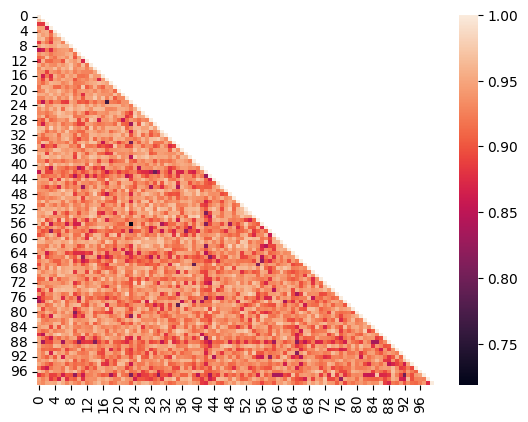

In [49]:
# consistency of shared component across group label perturbations
Vs_gmn_perms = [ases[0] for ases in permut_gmn_mats]
plot_sim_metric_heatmap(Vs_gmn_perms, metric=cos_sim)

In [73]:
metric= lambda x, y: x @ y

region_dists_gmn1 = cluster_distance_matrix(Ws_gmn[0], regions, metric, regions_of_interest)
region_dists_gmn2 = cluster_distance_matrix(Ws_gmn[1], regions, metric, regions_of_interest)

region_dists_mn1 = cluster_distance_matrix(Ws_mn[0], regions, metric, regions_of_interest)
region_dists_mn2 = cluster_distance_matrix(Ws_mn[1], regions, metric, regions_of_interest)

mn_reg_dists = region_dists_mn2 - region_dists_mn1
gmn_reg_dists = region_dists_gmn2 - region_dists_gmn1

In [74]:
Ws_aligned_perms_gmn = [align_latent_spaces(ases[1:3]) for ases in permut_gmn_mats]
Ws_aligned_perms_mn = [align_latent_spaces(ases) for ases in permut_mn_mats]

Ws_perms_gmn = [ases[1:3] for ases in permut_gmn_mats]
Ws_perms_mn = permut_mn_mats



gmn_region_dist_diffs_over_perms = [cluster_distance_matrix(ases[1], regions, metric, regions_of_interest) -
                                    cluster_distance_matrix(ases[0], regions, metric, regions_of_interest)
                                    for ases in Ws_perms_gmn]

mn_region_dist_diffs_over_perms = [cluster_distance_matrix(ases[1], regions, metric, regions_of_interest) -
                                   cluster_distance_matrix(ases[0], regions, metric, regions_of_interest)
                                   for ases in Ws_perms_mn]


In [75]:
p_values_perm_gmn = np.mean(np.abs(np.stack(gmn_region_dist_diffs_over_perms)) >= np.abs(gmn_reg_dists.values), 0)
p_values_perm_mn = np.mean(np.abs(np.stack(mn_region_dist_diffs_over_perms)) >= np.abs(mn_reg_dists.values), 0)

In [76]:
from statsmodels.stats.multitest import multipletests

triu_mask = np.triu_indices(len(regions_of_interest), k=0)
adjusted_p_values_gmn = multipletests(p_values_perm_gmn[triu_mask], method='fdr_bh')[1]
adjusted_p_values_mn = multipletests(p_values_perm_mn[triu_mask], method='fdr_bh')[1]

adjusted_p_values_gmn = upper_tri_list_to_matrix(adjusted_p_values_gmn)
adjusted_p_values_mn = upper_tri_list_to_matrix(adjusted_p_values_mn)

BH-corrected p-values


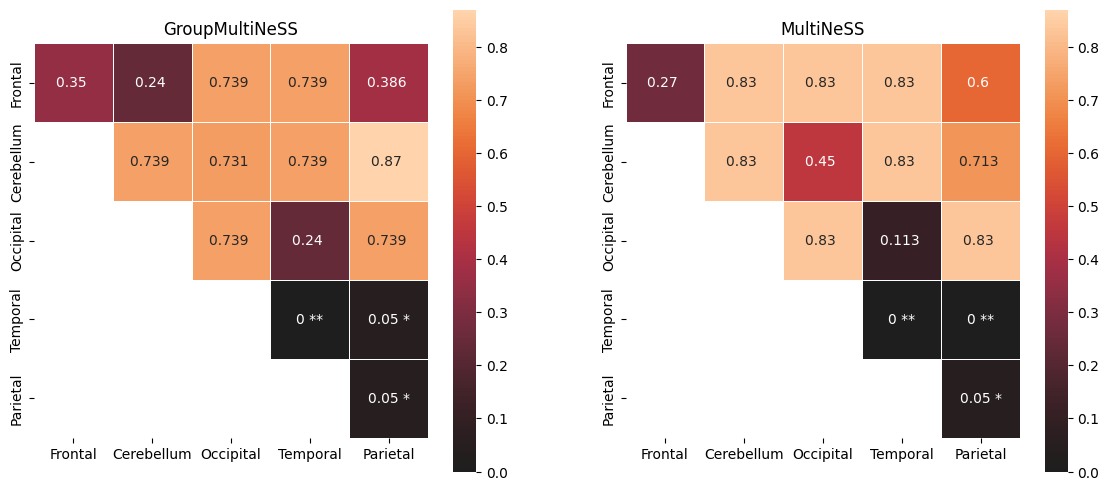

Raw p-values


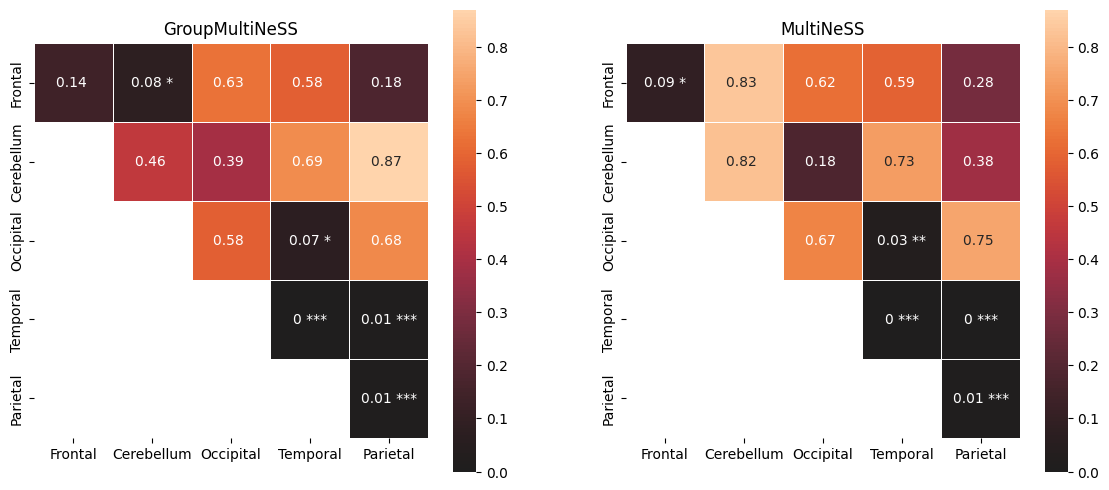

In [99]:
# vmin = min(mn_reg_dists.values.min(), gmn_reg_dists.values.min())
# vmax = max(mn_reg_dists.values.max(), gmn_reg_dists.values.max())

vmin = min(adjusted_p_values_mn.min(), adjusted_p_values_gmn.min())
vmax = max(adjusted_p_values_mn.max(), adjusted_p_values_gmn.max())

print("BH-corrected p-values")
fig, axs = plt.subplots(1, 2, figsize=(14,6))


significance_heatmap(adjusted_p_values_gmn, adjusted_p_values_gmn, 
                     regions_of_interest, ax=axs[0], title="GroupMultiNeSS", 
                     vmin=vmin, vmax=vmax, crit_pvals=(0.01, 0.05))
significance_heatmap(adjusted_p_values_mn, adjusted_p_values_mn, 
                     regions_of_interest, ax=axs[1], title="MultiNeSS", vmin=vmin, vmax=vmax, 
                     crit_pvals=(0.01, 0.05))
plt.show()


vmin = min(p_values_perm_mn.min(), p_values_perm_gmn.min())
vmax = max(p_values_perm_mn.max(), p_values_perm_gmn.max())

print("Raw p-values")
fig, axs = plt.subplots(1, 2, figsize=(14,6))
significance_heatmap(p_values_perm_gmn, p_values_perm_gmn, 
                     regions_of_interest, ax=axs[0], title="GroupMultiNeSS", 
                     vmin=vmin, vmax=vmax, crit_pvals=(0.01, 0.05, 0.1))
significance_heatmap(p_values_perm_mn, p_values_perm_mn, 
                     regions_of_interest, ax=axs[1], title="MultiNeSS", 
                     vmin=vmin, vmax=vmax, crit_pvals=(0.01, 0.05, 0.1))
plt.show()

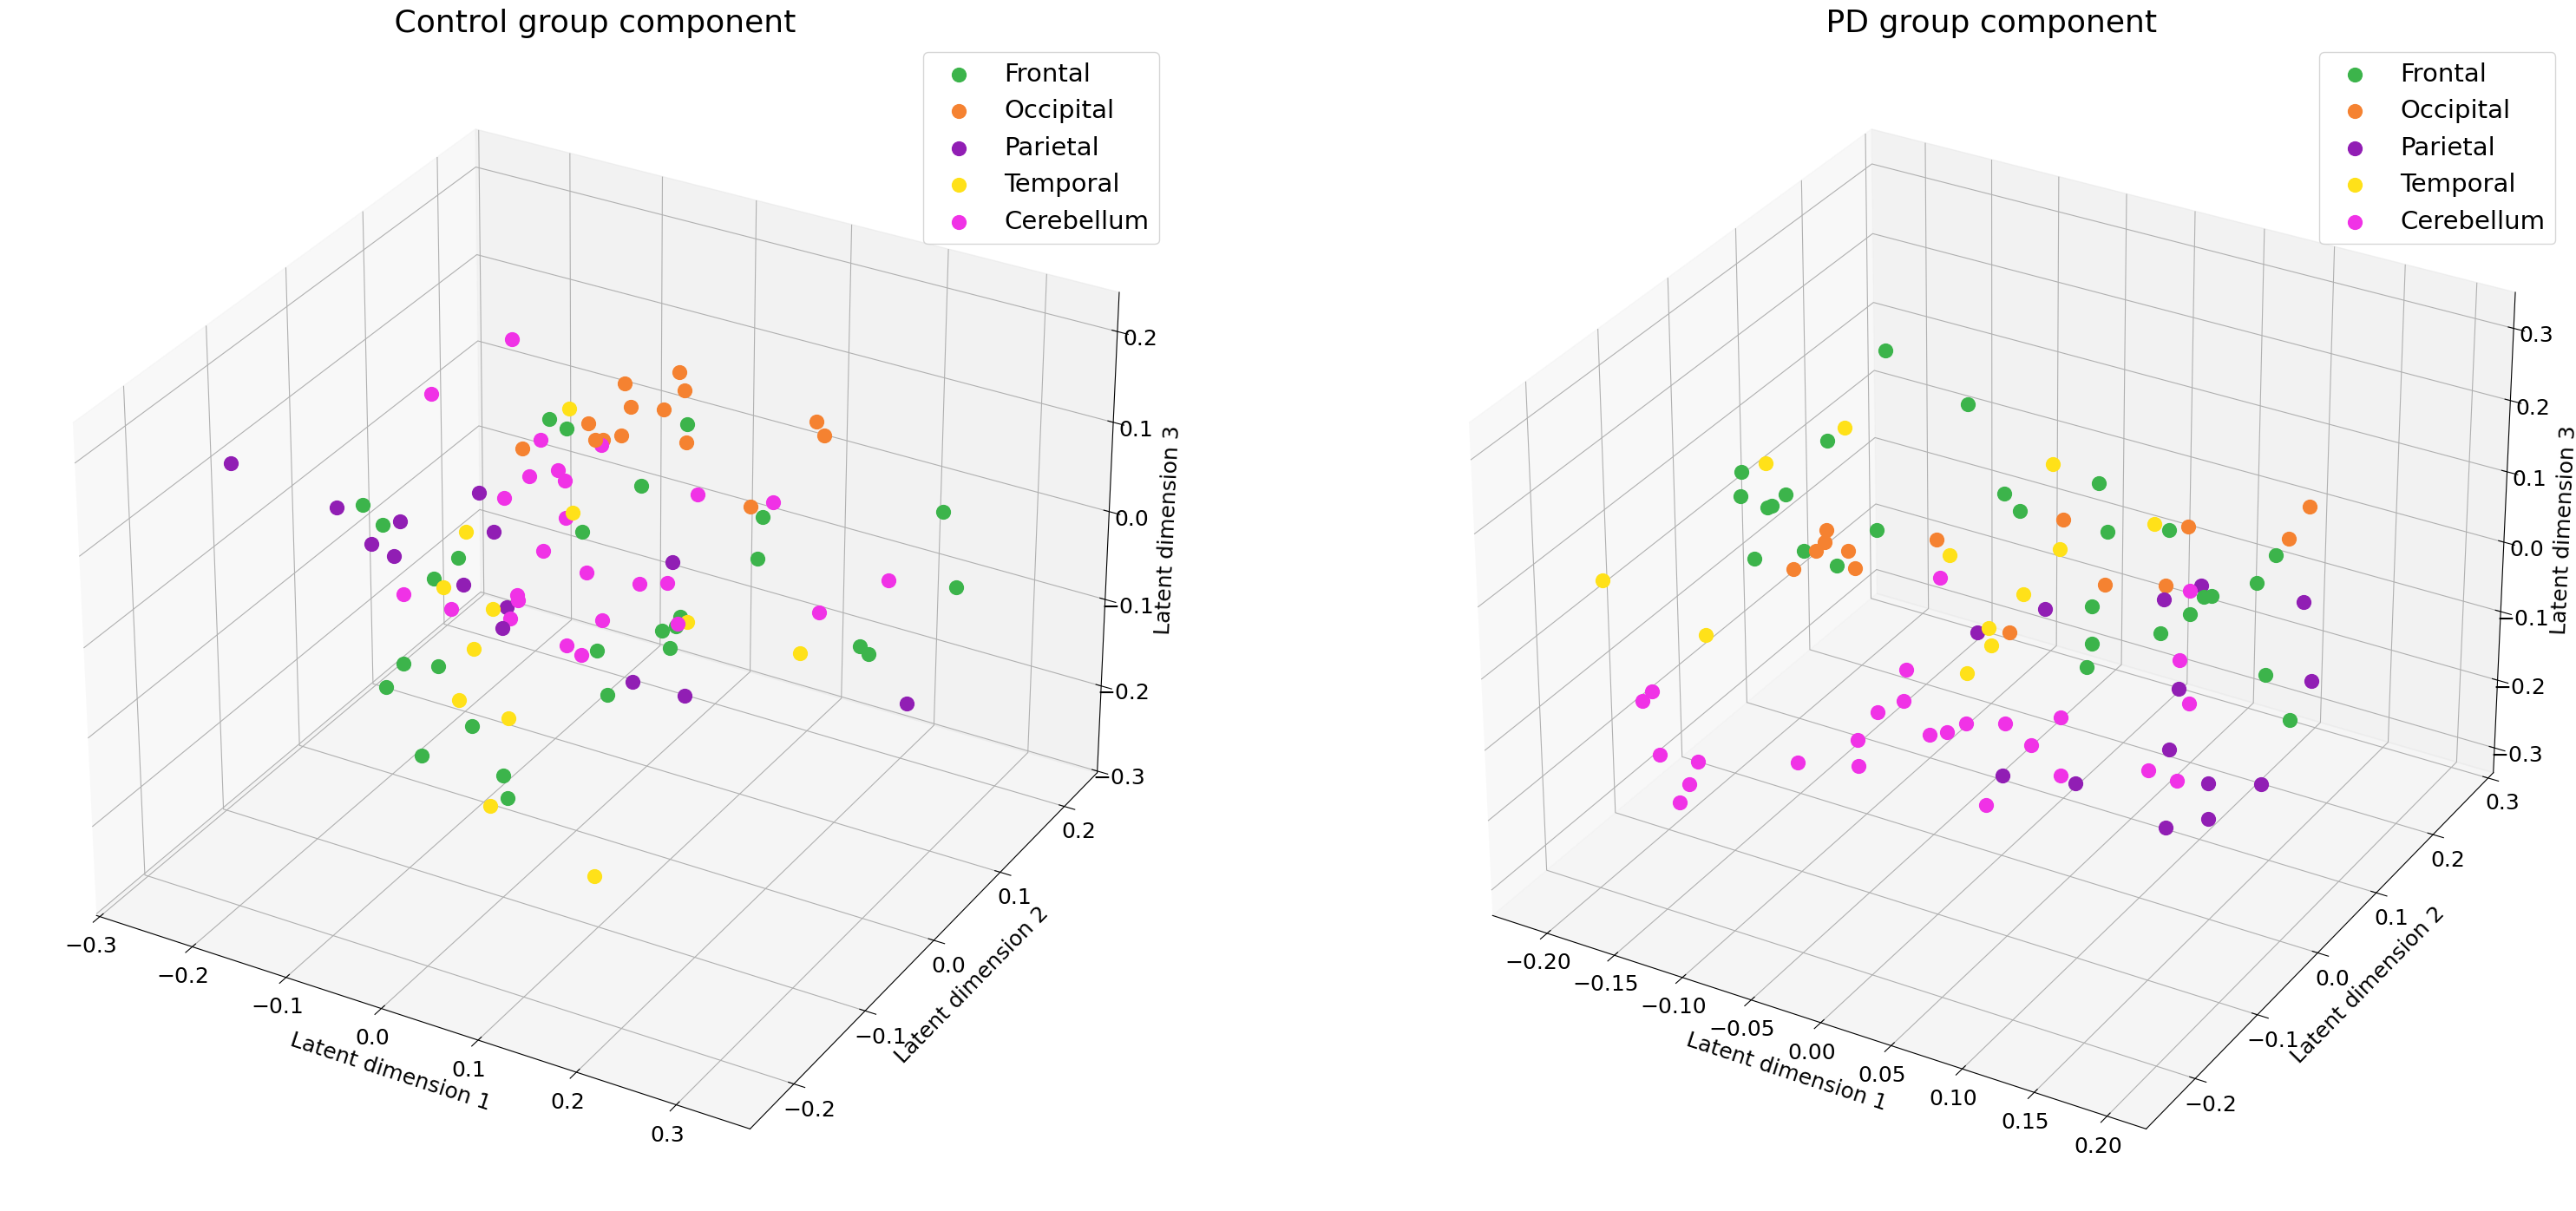

In [96]:
fontsize=18
markersize=130

colors = ["#f032e6", "#3cb44b", "#e6194b", "#0082c8", "#f58231", "#911eb4", "pink", "#ffe119"]
node_type_2_color = dict(zip(np.unique(regions), colors))
node_shapes = None
alpha = 1

fig = plt.figure(figsize=(20, 20))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plt.subplots_adjust(right=1.6)


for i, ax,  in enumerate([ax1, ax2]):
    plot_latent_positions(Ws_gmn_aligned[i][regions_mask], 
                          node_types=regions[regions_mask], 
                          node_shapes=node_shapes,
                          node_type_2_color=node_type_2_color,
                          title=f" {','.join(index_2_group[i])} group component", 
                          ax=ax, 
                          fontsize=fontsize, dims=(0, 1, 2),
                          markersize=markersize, alpha=alpha)
    
# plt.savefig("Figures/3D_group_compariosn_taowu.png", dpi=200, bbox_inches="tight")

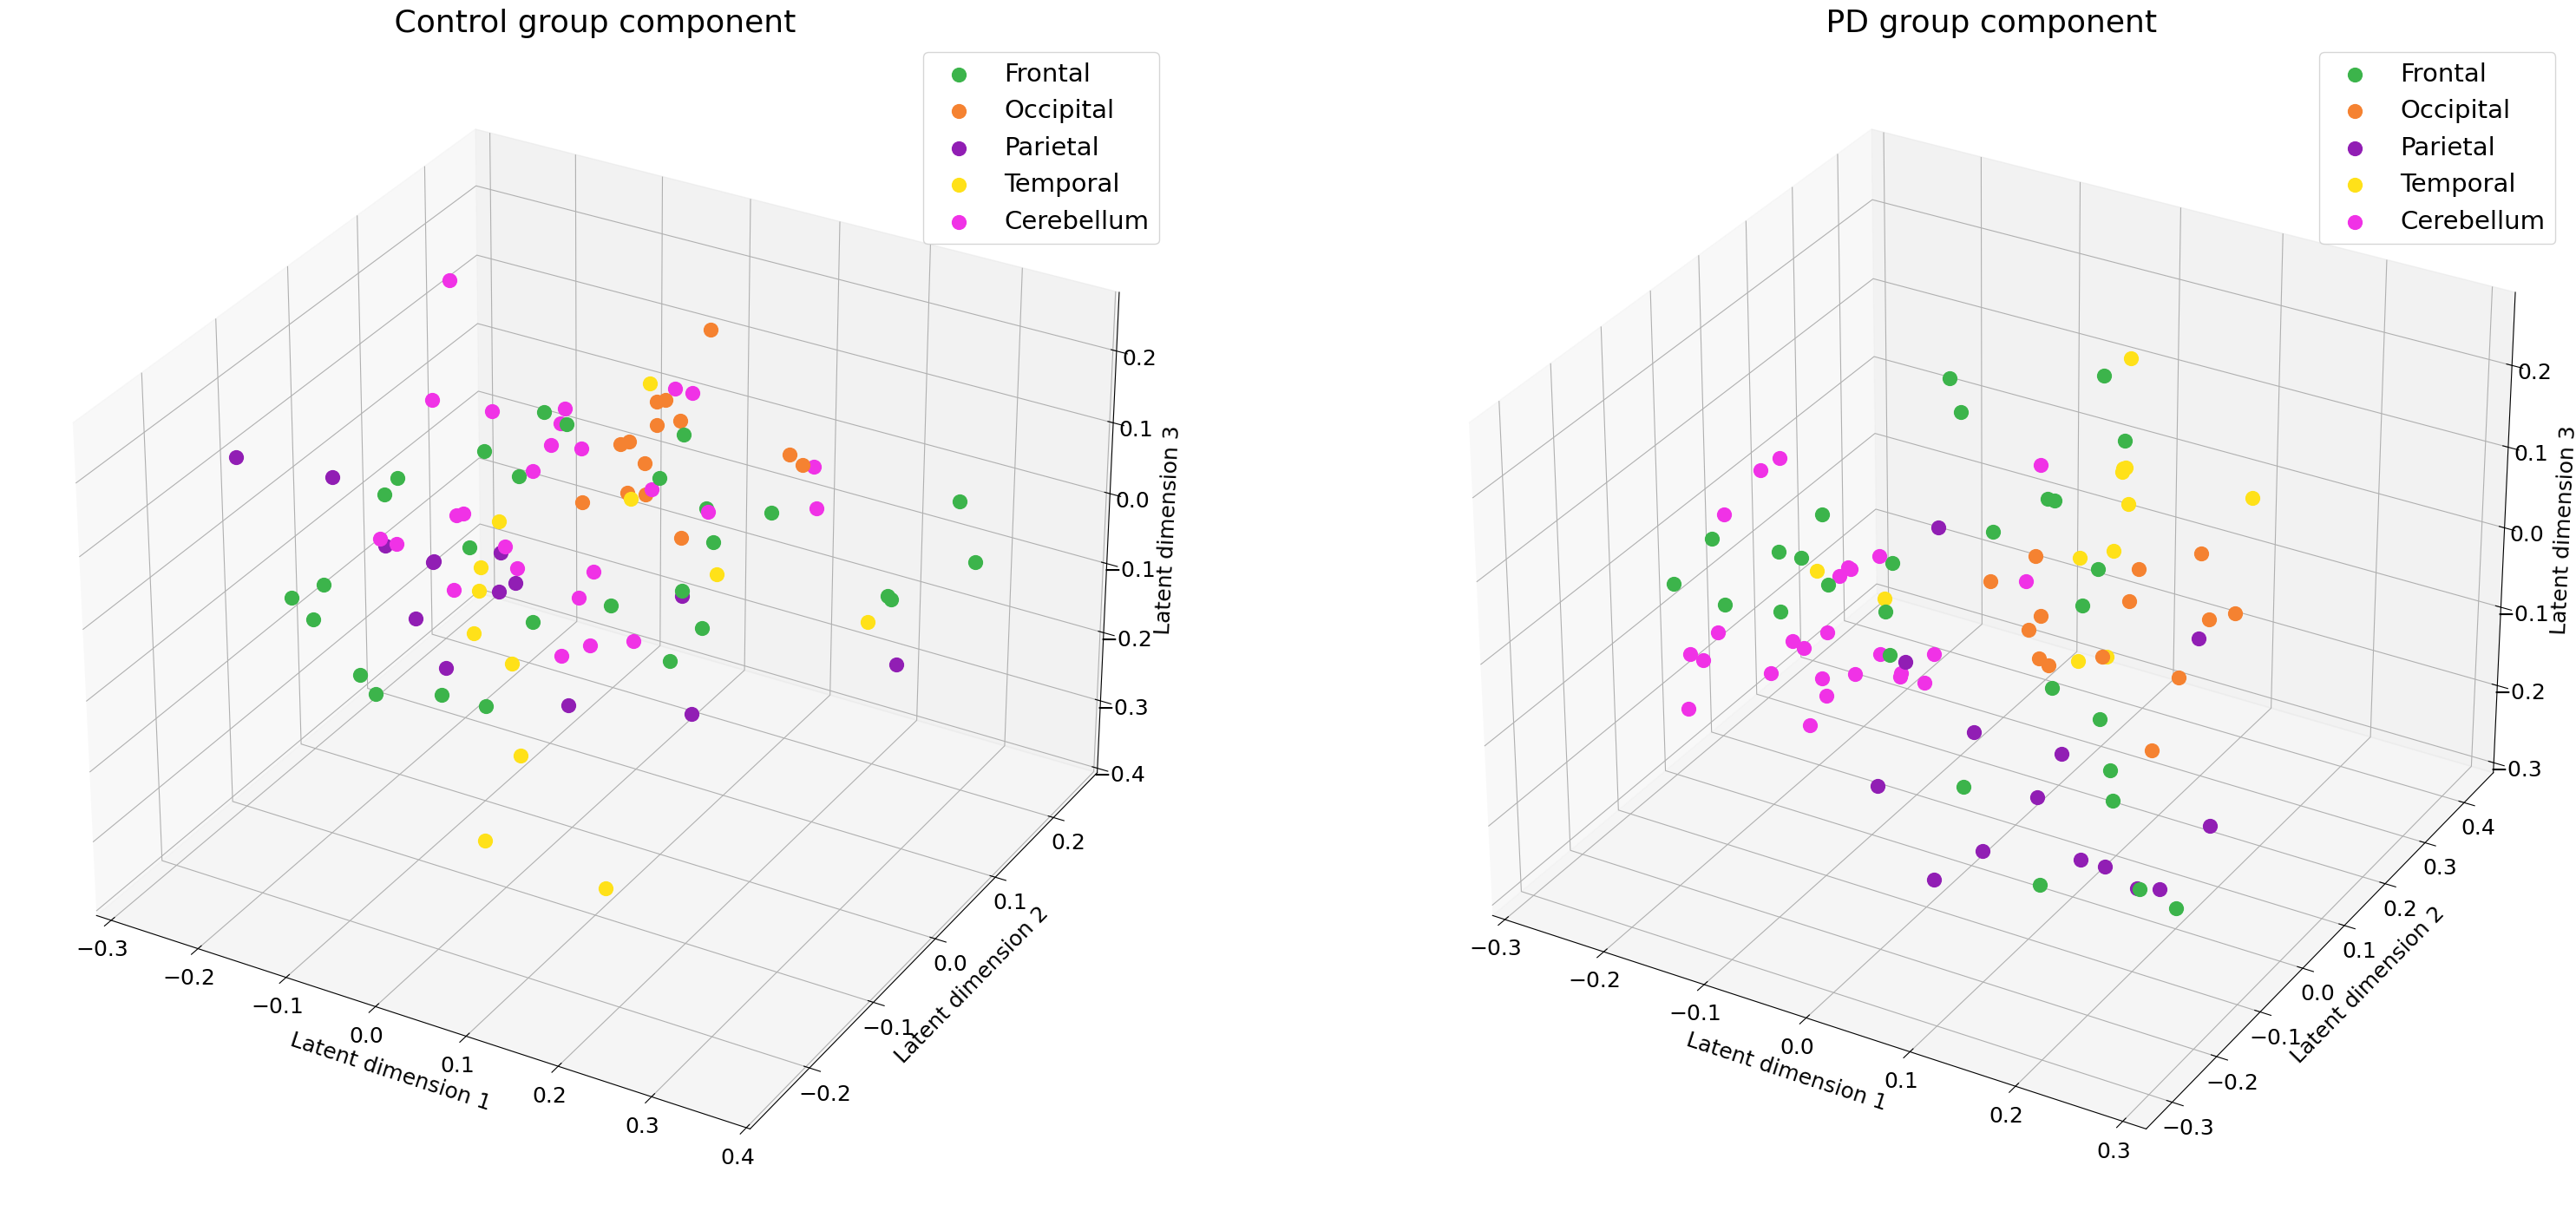

In [376]:
from utils import make_group_averages

fontsize=18
markersize=130


fig = plt.figure(figsize=(20, 20))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plt.subplots_adjust(right=1.6)

for i, ax,  in enumerate([ax1, ax2]):
    plot_latent_positions(Ws_mn_aligned[i][regions_mask], 
                          node_types=regions[regions_mask], 
                          node_shapes=node_shapes,
                          node_type_2_color=node_type_2_color,
                          title=f" {','.join(index_2_group[i])} group component", 
                          ax=ax, 
                          fontsize=fontsize, dims=(0, 1, 2),
                          markersize=markersize, alpha=alpha)

plt.savefig("Figures/3D_group_compariosn_taowu_mn.png", dpi=200, bbox_inches="tight")

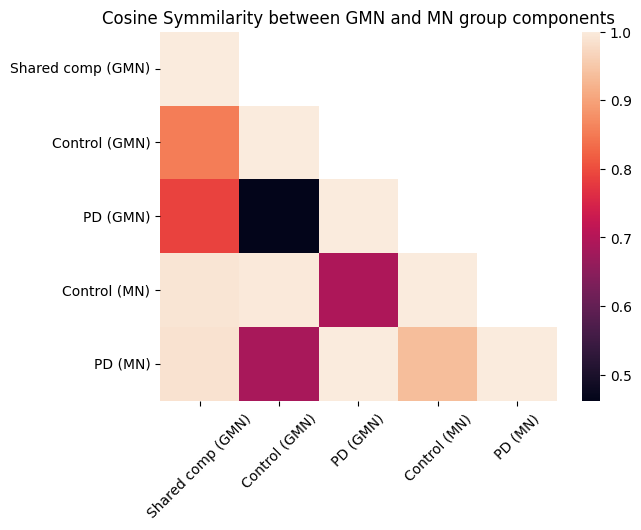

In [316]:
plot_sim_metric_heatmap([S, *Qs, *Qs_mn], cos_sim, 
                        labels = ["Shared comp (GMN)"] 
                               + [gl[0] + " (GMN)" for gl in group_labels]
                               + [gl[0] + " (MN)" for gl in group_labels], 
                        title="Cosine Symmilarity between GMN and MN group components")